# Part 4 — Rule Set Generation

Generate simulation parameters for any drug + indication by querying **10 biomedical databases**  
and synthesizing the results through a **3-stage LLM pipeline** (Gemini 2.0 Flash).

**What this produces:**
- AE profile (incidence, onset timing, grade distribution)
- Demographics (age, sex, race, ECOG)
- Dosing regimen and administration schedule
- Efficacy parameters (ORR, PFS, OS)
- Dose modification rules and AE cascades

**Runtime:** ~3-5 minutes per drug (most time spent on LLM calls)

---

This notebook is part of the **MedGemma Clinical Trial Engine** pipeline:

```
Part 1  Visual AE Detection ─── MedGemma 1.5 + MedSigLIP (image → AE classification)
Part 2  Cough Detection ──────── HeAR + 2-Stage Classifier (audio → cough type)
Part 3  Care AI Conversation ── MedGemma-4B as virtual nurse (multi-turn dialogue → AE detection)
    ↓
Part 4  Rule Set Generation ─── 10 biomedical DBs → LLM synthesis → simulation parameters
Part 5  Simulation Pipeline ─── Hazard functions + LLM enrichment → synthetic clinical trial data
    ↓
Part 6  Anti-Hallucination ──── RLFR fine-tuning to reduce fabrication in medical text
Part 7  Doc Agent ──────────────  CRF data → MedWatch 3500A pharmacovigilance reports
```


---
## 0. Environment Setup

The rule engine is included in this repository at `src/ruleset_generation/rule_engine/`.  
You need a **Gemini API key** ([get one free](https://aistudio.google.com/apikey)).


In [ ]:
# Run once to install dependencies
!pip install -q openai pydantic pydantic-settings httpx requests aiohttp numpy pandas seaborn matplotlib jsonschema typer rich python-dotenv google-genai

In [1]:
import sys, os
from pathlib import Path

ROOT = Path('/data2/workspace/ClinicalTrialEngine')
RULESET_DIR = ROOT / 'src' / 'ruleset_generation'
os.chdir(RULESET_DIR)
sys.path.insert(0, str(RULESET_DIR))
sys.path.insert(0, str(ROOT))

# Load .env if present
env_path = ROOT / '.env'
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())

print(f'Rule engine: {RULESET_DIR}')
print(f'Contents: {[f.name for f in RULESET_DIR.iterdir() if not f.name.startswith(".")][:10]}')


Rule engine: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation
Contents: ['scripts', 'requirements.txt', 'README.md', 'schema', 'output', 'CLAUDE.md', 'rule_sets', 'venv', 'ground_truth', 'setup.sh']


In [2]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML, Markdown

PROJECT_ROOT = Path.cwd()  # same as RULESET_DIR after os.chdir()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.version.split()[0]}')


Project root: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation
Python: 3.10.12


In [3]:
import sys, os, json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from IPython.display import display, HTML, Markdown

# Ensure rule_engine is importable

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

Project root: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation
Python: 3.10.12


### Download Data Files (optional — skip if you want)

The pipeline can run with just the 6 **API sources** (DailyMed, CT.gov, OpenFDA, PubChem, ChEMBL, PubMed) and no local data. However, downloading the 3 local databases improves accuracy by adding OnSIDES ADE validation, PrimeKG knowledge graph context, and DrugBank pharmacology data.

Run `setup.sh` to download and process them automatically:

| Dataset | Size | What It Provides |
|---------|------|------------------|
| **PrimeKG** | ~925 MB | Knowledge graph — drug-disease, drug-gene relationships |
| **DrugBank** | ~170 MB | Drug-target binding, pharmacological properties |
| **OnSIDES** | ~2 GB | 7.1M validated drug-ADE pairs from 51,460 FDA labels |

**Skip this cell** if you don't need local data or have already run `setup.sh`.

In [4]:
# Run setup.sh to download data (takes ~10-15 min on first run)
# If data is already downloaded, use --no-data to just verify
!bash setup.sh --no-data

  Rule Discovery — Quick Setup (no data)

[1/2] Virtual environment already exists: venv/

[2/2] Installing Python dependencies...


    Done.

Checking existing data files...
  ✗ data/primekg/nodes.csv  MISSING
  ✗ data/primekg/edges.csv  MISSING
  ✗ data/drugbank/drugbank_vocabulary.csv  MISSING
  ✗ data/onsides/onsides.db  MISSING
  ✗ data/primekg_augmented/edges_exhaustion_augmented.csv  MISSING
  - data/pds/  (not downloaded — optional)


  Setup Complete

Next steps:
  1. Set your Gemini API key:
     export RULE_ENGINE_LLM_API_KEY="your-key"

  2. Generate a rule set:
     venv/bin/python -m rule_engine generate-single "Etoposide+Cisplatin" "Small Cell Lung Cancer" -o output --multi-stage

  3. Validate output:
     venv/bin/python scripts/validate_target_schema.py output/
     venv/bin/python scripts/analyze_hallucinations.py output/


### Gemini API Key (Required)

The pipeline uses **Gemini 2.0 Flash** via OpenAI-compatible endpoint.  
Get a free API key at https://aistudio.google.com/apikey

In [5]:
if not os.environ.get("RULE_ENGINE_LLM_API_KEY"):
    os.environ.setdefault("RULE_ENGINE_LLM_API_KEY", os.environ.get("GOOGLE_API_KEY", ""))

assert os.environ.get("RULE_ENGINE_LLM_API_KEY"), (
    "RULE_ENGINE_LLM_API_KEY not set. "
    "Add GOOGLE_API_KEY=... to .env or set RULE_ENGINE_LLM_API_KEY manually."
)
print(f"Gemini API key: ...{os.environ['RULE_ENGINE_LLM_API_KEY'][-6:]}")

Gemini API key: ...R5Kzco


### Define Drug + Indication

We'll use **Etoposide + Cisplatin** for Small Cell Lung Cancer as the example. You can change `DRUGS` and `INDICATION` below to generate rulesets for any drug-indication pair.

In [6]:
# Change these to generate rulesets for different drugs
DRUGS = ["Etoposide", "Cisplatin"]
INDICATION = "Small Cell Lung Cancer"

DRUG_LABEL = "+".join(DRUGS).lower()
INDICATION_LABEL = INDICATION.lower().replace(" ", "_")
OUTPUT_SUBDIR = f"{DRUG_LABEL}_{INDICATION_LABEL}"

print(f"Drug(s):     {' + '.join(DRUGS)}")
print(f"Indication:  {INDICATION}")
print(f"Output dir:  output/{OUTPUT_SUBDIR}/")

Drug(s):     Etoposide + Cisplatin
Indication:  Small Cell Lung Cancer
Output dir:  output/etoposide+cisplatin_small_cell_lung_cancer/


In [7]:
from rule_engine.config import RuleEngineConfig

config = RuleEngineConfig()

print(f"LLM Model:    {config.llm_model}")
print(f"Rate Limit:   {config.rate_limit_rpm} RPM")
print(f"OnSIDES DB:   {config.onsides_db} {'(exists)' if config.onsides_db.exists() else '(MISSING)'}")
print(f"PrimeKG:      {config.primekg_nodes} {'(exists)' if config.primekg_nodes.exists() else '(MISSING)'}")
print(f"PDS data:     {config.pds_data_dir} {'(exists)' if config.pds_data_dir.exists() else '(not downloaded)'}")

LLM Model:    gemini-2.0-flash
Rate Limit:   150 RPM
OnSIDES DB:   /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/onsides/onsides.db (MISSING)
PrimeKG:      /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv (MISSING)
PDS data:     /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/pds (not downloaded)


---
## 1. Evidence Collection

The pipeline queries **10 databases** in parallel, organized into 3 categories:

| Category | Sources | Access |
|----------|---------|--------|
| **API** (6) | DailyMed, ClinicalTrials.gov, OpenFDA, PubChem, ChEMBL, PubMed | Public, no credentials |
| **Local DB** (3) | PrimeKG, DrugBank, OnSIDES | Downloaded by `setup.sh` |
| **Remote** (1) | Project Data Sphere | PDS account required |

### 1a. API Sources (6 databases, no credentials needed)

These query public REST APIs in real time.

In [8]:
from rule_engine.evidence.dailymed import fetch_dailymed
from rule_engine.evidence.clinical_trials import fetch_clinical_trials, fetch_clinical_trials_combo
from rule_engine.evidence.openfda import fetch_openfda_aes
from rule_engine.evidence.pubchem import fetch_pubchem
from rule_engine.evidence.chembl import fetch_chembl
from rule_engine.evidence.literature import fetch_literature

print("All API evidence modules loaded.")

All API evidence modules loaded.


#### DailyMed — FDA-Approved Drug Labels

DailyMed provides the **official FDA label** for each drug, including structured AE incidence tables with grade 3-4 breakdowns. This is the most authoritative source for AE frequencies.

Look for: number of AEs found, whether a boxed warning exists, and the sample AE table showing incidence percentages.

In [9]:
# DailyMed — FDA-approved drug labels (AE incidence tables, dosage, boxed warnings)
dm_results = {}
for drug in DRUGS:
    dm = await fetch_dailymed(drug)
    dm_results[drug] = dm
    status = f"{len(dm.ae_table)} AEs" if dm.found else "NOT FOUND"
    boxed = ", has boxed warning" if dm.boxed_warning else ""
    print(f"  DailyMed [{drug}]: {status}{boxed}")

# Show sample AE table
for drug, dm in dm_results.items():
    if dm.ae_table:
        print(f"\n  Sample AEs from {drug} label:")
        for ae in dm.ae_table[:5]:
            print(f"    {ae['term']:30s}  {ae['incidence_pct']:5.1f}%  (grade 3-4: {ae.get('grade34_pct', 'N/A')}%)")

  DailyMed [Etoposide]: 0 AEs, has boxed warning


  DailyMed [Cisplatin]: 0 AEs, has boxed warning


#### ClinicalTrials.gov — Trial Demographics & Endpoints

ClinicalTrials.gov provides trial-level data: how many trials exist, what phase they reached, baseline demographics (age, sex), and reported AEs. For combination therapy, a dedicated combo search finds trials that used the exact drug combination.

In [10]:
# ClinicalTrials.gov — trial demographics, endpoints, reported AEs
ct_results = {}
for drug in DRUGS:
    ct = await fetch_clinical_trials(drug, INDICATION)
    ct_results[drug] = ct
    print(f"  CT.gov [{drug}]: {ct.trial_count} trials, max phase {ct.max_phase}, "
          f"{len(ct.reported_aes)} reported AEs")

# Combo trial search (for combination therapy)
if len(DRUGS) > 1:
    combo_ct = await fetch_clinical_trials_combo(DRUGS, INDICATION)
    print(f"  CT.gov [combo]: {combo_ct.trial_count} trials")
    if combo_ct.baseline_demographics:
        bd = combo_ct.baseline_demographics
        print(f"    Demographics: age={bd.get('age_mean', '?')} +/- {bd.get('age_std', '?')}, "
              f"male={bd.get('sex_male', '?')}, female={bd.get('sex_female', '?')}")

  CT.gov [Etoposide]: 50 trials, max phase 3, 108 reported AEs


  CT.gov [Cisplatin]: 50 trials, max phase 4, 127 reported AEs


  CT.gov [combo]: 50 trials
    Demographics: age=? +/- ?, male=140, female=25


#### OpenFDA/FAERS — Post-Market Adverse Event Reports

The FDA Adverse Event Reporting System (FAERS) contains real-world AE reports submitted after drug approval. Useful for rare AEs not captured in clinical trials and for time-to-onset data.

In [11]:
# OpenFDA/FAERS — post-market adverse event reports
fda_results = {}
for drug in DRUGS:
    fda = await fetch_openfda_aes(drug)
    fda_results[drug] = fda
    print(f"  OpenFDA [{drug}]: {fda.total_ae_reports} reports, "
          f"{len(fda.top_adverse_events)} top AEs, "
          f"timing data: {'Yes' if fda.has_timing_data else 'No'}")

  OpenFDA [Etoposide]: 128693 reports, 100 top AEs, timing data: Yes


  OpenFDA [Cisplatin]: 137584 reports, 100 top AEs, timing data: Yes


#### PubChem, ChEMBL & PubMed — Molecular Properties, Bioactivity & Literature

These three sources provide complementary chemical and literature context:
- **PubChem**: Molecular weight, logP, Lipinski violations (drug-likeness)
- **ChEMBL**: Mechanism of action, bioactivity data, max clinical phase
- **PubMed**: Literature co-occurrence score (how often drug + indication appear together)

In [12]:
# PubChem, ChEMBL, PubMed — molecular properties, bioactivity, literature
for drug in DRUGS:
    pc = await fetch_pubchem(drug)
    ch = await fetch_chembl(drug)
    lit = await fetch_literature(drug, INDICATION)
    print(f"  {drug}:")
    print(f"    PubChem: MW={pc.molecular_weight}, logP={pc.logp}, Lipinski violations={pc.lipinski_violations}")
    print(f"    ChEMBL:  MoA='{ch.mechanism_of_action or 'N/A'}', phase={ch.max_phase}")
    print(f"    PubMed:  {lit.article_count} articles, co-occurrence score={lit.cooccurrence_score:.2f}")

  Etoposide:
    PubChem: MW=588.6, logP=0.6, Lipinski violations=2
    ChEMBL:  MoA='DNA topoisomerase II alpha inhibitor', phase=4
    PubMed:  3223 articles, co-occurrence score=1.00


  Cisplatin:
    PubChem: MW=300.05, logP=None, Lipinski violations=0
    ChEMBL:  MoA='N/A', phase=0
    PubMed:  7750 articles, co-occurrence score=1.00


#### Visualize: DailyMed AE Frequencies

The chart below shows the **top 15 AEs by incidence** from each drug's FDA label. This is what the pipeline uses as its primary AE frequency source (dampened by 0.5x since label frequencies are aggregate worst-case values).

**What to look for:**
- **Red bars (>30%)**: Very common AEs — these should definitely appear in the final ruleset
- **Orange bars (10-30%)**: Common AEs — most will be retained after pruning
- **Blue bars (<10%)**: Less common — may be pruned if not corroborated by other sources

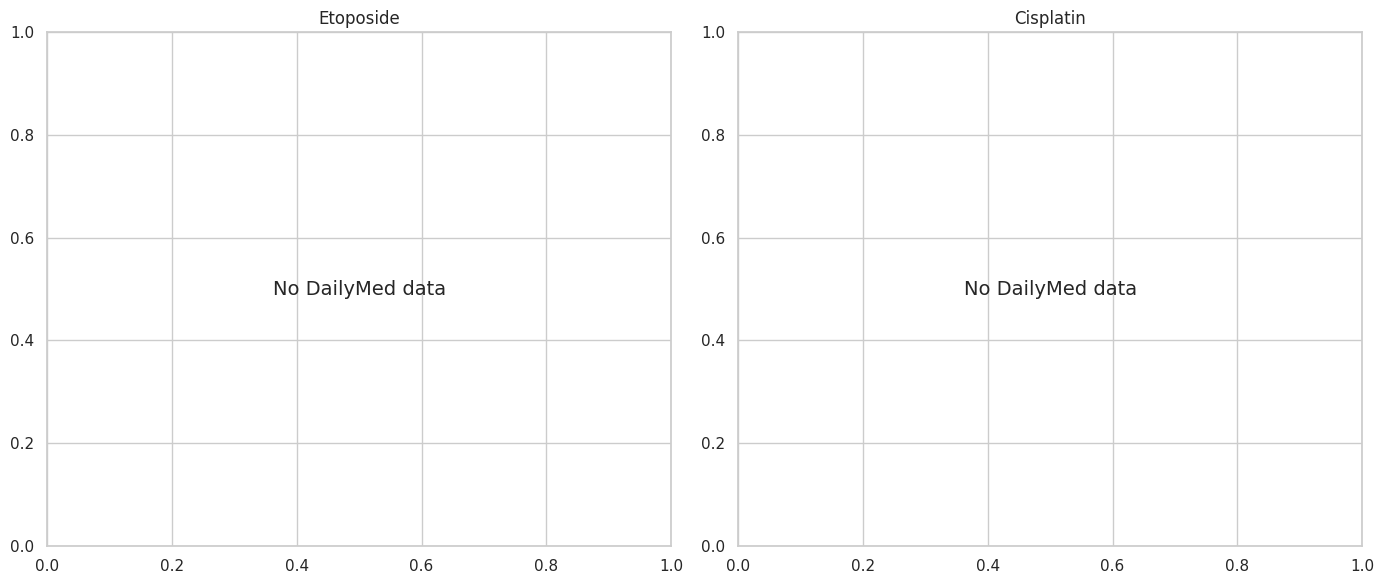

In [13]:
# Plot DailyMed AE frequencies for each drug
fig, axes = plt.subplots(1, len(DRUGS), figsize=(7 * len(DRUGS), 6), squeeze=False)

for idx, (drug, dm) in enumerate(dm_results.items()):
    ax = axes[0][idx]
    if dm.ae_table:
        top = sorted(dm.ae_table, key=lambda x: x["incidence_pct"], reverse=True)[:15]
        terms = [ae["term"][:25] for ae in top]
        freqs = [ae["incidence_pct"] for ae in top]
        colors = ["#e74c3c" if f > 30 else "#f39c12" if f > 10 else "#3498db" for f in freqs]
        ax.barh(terms[::-1], freqs[::-1], color=colors[::-1])
        ax.set_xlabel("Incidence (%)")
        ax.set_title(f"{drug} — DailyMed AE Table (top 15)")
    else:
        ax.text(0.5, 0.5, "No DailyMed data", ha="center", va="center", fontsize=14)
        ax.set_title(drug)

plt.tight_layout()
plt.show()

### 1b. Local Database Sources (3 databases)

These read from files downloaded by `setup.sh`. No internet needed.

In [14]:
from rule_engine.evidence.local_dbs import fetch_drugbank, fetch_primekg
from rule_engine.evidence.onsides import fetch_onsides

for drug in DRUGS:
    # DrugBank — drug-target binding, pharmacology
    db = await fetch_drugbank(drug, config)
    print(f"  DrugBank [{drug}]: found={db.found}, targets={len(db.targets)}, DDIs={db.ddi_count}")
    if db.moa:
        print(f"    MoA: {db.moa[:100]}...")

    # PrimeKG — knowledge graph (drug-disease, drug-gene)
    kg = await fetch_primekg(drug, INDICATION, config)
    print(f"  PrimeKG  [{drug}]: found={kg.found}, diseases={len(kg.disease_associations)}, "
          f"genes={len(kg.gene_targets)}")

    # OnSIDES — 7.1M validated drug-ADE pairs from FDA labels
    ons = await fetch_onsides(drug, config)
    print(f"  OnSIDES  [{drug}]: found={ons.found}, {ons.total_pairs} ADE pairs, "
          f"boxed warnings={len(ons.boxed_warning_aes)}")
    if ons.boxed_warning_aes:
        print(f"    Boxed warnings: {', '.join(ons.boxed_warning_aes[:5])}")
    print()

DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv


PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv


PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


  DrugBank [Etoposide]: found=False, targets=0, DDIs=0
  PrimeKG  [Etoposide]: found=False, diseases=0, genes=0
  OnSIDES  [Etoposide]: found=False, 0 ADE pairs, boxed warnings=0

  DrugBank [Cisplatin]: found=False, targets=0, DDIs=0
  PrimeKG  [Cisplatin]: found=False, diseases=0, genes=0
  OnSIDES  [Cisplatin]: found=False, 0 ADE pairs, boxed warnings=0



#### Visualize: OnSIDES ADE Pair Prediction Scores

OnSIDES uses a PubMedBERT model to extract drug-ADE pairs from FDA labels with confidence scores. Higher prediction scores indicate stronger evidence for the association.

**What to look for:**
- **Red bars**: Boxed warning AEs — these are injected into the final ruleset if missing
- **Score > 0.8**: High-confidence associations that corroborate DailyMed data
- Compare with DailyMed: AEs appearing in both sources have stronger evidence

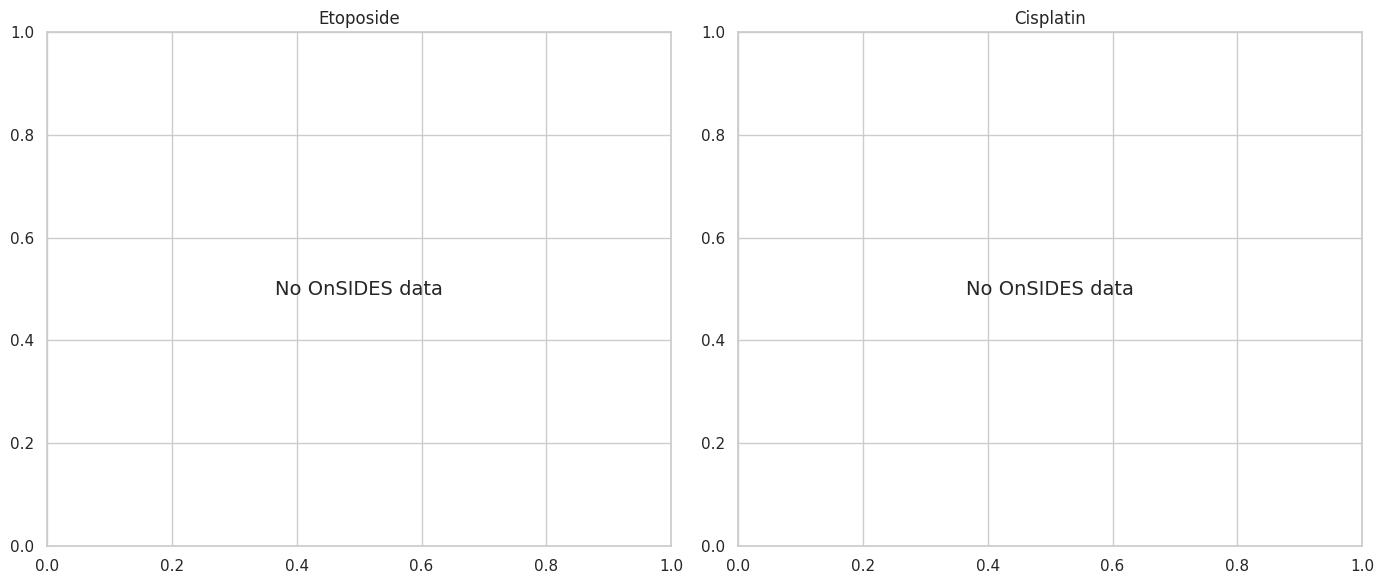

In [15]:
# OnSIDES top ADE pairs by prediction score
fig, axes = plt.subplots(1, len(DRUGS), figsize=(7 * len(DRUGS), 6), squeeze=False)

for idx, drug in enumerate(DRUGS):
    ax = axes[0][idx]
    ons = await fetch_onsides(drug, config)
    if ons.ae_pairs:
        top = sorted(ons.ae_pairs, key=lambda x: x["mean_pred_score"], reverse=True)[:15]
        terms = [p["pt_meddra_term"][:25] for p in top]
        scores = [p["mean_pred_score"] for p in top]
        colors = ["#e74c3c" if p.get("is_boxed_warning") else "#3498db" for p in top]
        ax.barh(terms[::-1], scores[::-1], color=colors[::-1])
        ax.set_xlabel("Prediction Score")
        ax.set_title(f"{drug} — OnSIDES Top ADE Pairs")
        # Legend
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(color="#e74c3c", label="Boxed Warning"),
                           Patch(color="#3498db", label="Standard")], loc="lower right")
    else:
        ax.text(0.5, 0.5, "No OnSIDES data", ha="center", va="center", fontsize=14)
        ax.set_title(drug)

plt.tight_layout()
plt.show()

### 1c. Remote Source — Project Data Sphere (optional)

PDS provides **patient-level** data from real clinical trials.  
Requires a free account at https://projectdatasphere.org

If PDS data is cached locally (from a previous `setup.sh` run), it will be used even without live credentials.

In [16]:
from rule_engine.evidence.projectdatasphere import fetch_pds

pds = await fetch_pds(DRUGS, INDICATION, config)

if pds.found:
    t = pds.matched_trial
    d = pds.demographics
    print(f"  PDS match: trial={t.trial_id}, n={t.n_patients}, score={t.match_score:.2f}")
    print(f"  Demographics: n={d.n_patients}, age={d.age_mean:.1f} +/- {d.age_std:.1f}, "
          f"male={d.pct_male:.1f}%, female={d.pct_female:.1f}%")
    print(f"  AEs: {len(pds.ae_aggregates)} unique terms")
    print(f"  Efficacy: ORR={pds.efficacy.overall_response_rate_pct}%")
    print(f"  Regimen: {len(pds.regimen)} drugs")
    for r in pds.regimen:
        print(f"    {r.drug}: {r.median_dose} {r.dose_unit} ({r.route})")
else:
    print("  PDS: No matching trial found (or data not downloaded).")
    print("  The pipeline will use the other 9 sources.")

  PDS: No matching trial found (or data not downloaded).
  The pipeline will use the other 9 sources.


#### Visualize: PDS Demographics (if available)

If PDS matched a trial, these charts show the **real patient-level distributions** — far more accurate than aggregate summaries from ClinicalTrials.gov. PDS demographics always override CT.gov when available.

**What to look for:**
- **Age**: Is the distribution skewed? Oncology trials typically center around 60-65 years
- **Sex**: Many lung cancer trials skew male (60-70%)
- **ECOG**: Most trials enroll ECOG 0-1; ECOG 2+ patients are often excluded

In [17]:
if pds.found and pds.demographics.n_patients > 0:
    d = pds.demographics
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Age distribution (simulated from mean/std)
    ax = axes[0]
    ages = np.random.normal(d.age_mean, d.age_std, 1000)
    ages = ages[(ages >= 18) & (ages <= 95)]
    ax.hist(ages, bins=25, color="#3498db", edgecolor="white")
    ax.axvline(d.age_mean, color="red", linestyle="--", label=f"Mean={d.age_mean:.1f}")
    ax.set_xlabel("Age")
    ax.set_title(f"PDS Age Distribution (n={d.n_patients})")
    ax.legend()

    # Sex
    ax = axes[1]
    ax.pie([d.pct_male, d.pct_female], labels=["Male", "Female"],
           autopct="%1.1f%%", colors=["#3498db", "#e74c3c"], startangle=90)
    ax.set_title("Sex Distribution")

    # ECOG
    ax = axes[2]
    if d.ecog_distribution:
        ecog_labels = [f"ECOG {k}" for k in sorted(d.ecog_distribution.keys())]
        ecog_vals = [d.ecog_distribution[k] for k in sorted(d.ecog_distribution.keys())]
        ax.bar(ecog_labels, ecog_vals, color="#2ecc71")
        ax.set_ylabel("Proportion")
        ax.set_title("ECOG Performance Status")
    else:
        ax.text(0.5, 0.5, "No ECOG data", ha="center", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("PDS data not available — skipping visualization.")

PDS data not available — skipping visualization.


### Evidence Summary

In [18]:
# Collect all evidence via the orchestrator (same as pipeline does internally)
from rule_engine.evidence.collector import collect_evidence

print("Collecting all evidence via orchestrator (parallel)...")
bundle = await collect_evidence(DRUGS, INDICATION, config)
print("Done!\n")

# Summary table
rows = []
for drug in DRUGS:
    d = bundle.per_drug.get(drug)
    if d:
        rows.append({
            "Drug": drug,
            "DailyMed AEs": len(d.dailymed.ae_table) if d.dailymed.found else 0,
            "OpenFDA Reports": d.openfda.total_ae_reports,
            "OnSIDES Pairs": d.onsides.total_pairs,
            "ChEMBL Activities": d.chembl.activity_count,
            "DrugBank Targets": len(d.drugbank.targets),
        })

ct = bundle.clinical_trials
print("Per-Drug Evidence:")
for r in rows:
    print(f"  {r['Drug']:20s}  DailyMed={r['DailyMed AEs']:3d} AEs  OpenFDA={r['OpenFDA Reports']:6d} reports  "
          f"OnSIDES={r['OnSIDES Pairs']:4d} pairs  ChEMBL={r['ChEMBL Activities']:3d}  DrugBank={r['DrugBank Targets']:2d} targets")

print(f"\nShared Evidence:")
print(f"  ClinicalTrials.gov: {ct.trial_count} trials, {len(ct.reported_aes)} reported AEs")
print(f"  Combo trials:       {bundle.combo_trials.trial_count} trials")
print(f"  PrimeKG:            {bundle.primekg.found}")
print(f"  PDS:                {'matched' if bundle.pds.found else 'no match'}")

PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv


DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv


Done!

Per-Drug Evidence:
  Etoposide             DailyMed=  0 AEs  OpenFDA=128693 reports  OnSIDES=   0 pairs  ChEMBL= 13  DrugBank= 0 targets
  Cisplatin             DailyMed=  0 AEs  OpenFDA=137584 reports  OnSIDES=   0 pairs  ChEMBL=  6  DrugBank= 0 targets

Shared Evidence:
  ClinicalTrials.gov: 100 trials, 108 reported AEs
  Combo trials:       50 trials
  PrimeKG:            False
  PDS:                no match


---
## 2. Run the Full Pipeline

Now we run the complete multi-stage LLM pipeline:  
**Stage 1** (5 parallel extractions) → **Stage 2** (grounding) → **Stage 3** (synthesis) → **Overrides** → **Validation** → **Output**

This takes ~2-3 minutes and makes 7-12 LLM calls.

**What to expect:**
- Progress messages as each stage completes
- Stage 2 may report a JSON parse failure — this is normal (100% failure rate with Gemini; programmatic overrides compensate)
- The pipeline auto-corrects hallucination patterns and writes split output (`base.json` + type overlay)
- Any warnings are logged but non-fatal

In [19]:
from rule_engine.pipeline import run_pipeline
import time

print(f"Running pipeline for {' + '.join(DRUGS)} / {INDICATION}...")
print(f"This will make 7-12 LLM calls to Gemini 2.0 Flash.\n")

start = time.time()
result = await run_pipeline([(DRUGS, INDICATION)], config)
elapsed = time.time() - start

print(f"\nPipeline completed in {elapsed:.1f}s")
print(f"  Successful: {len(result.successful)}")
print(f"  Failed:     {len(result.failed)}")

if result.successful:
    drugs_out, ind_out, out_path = result.successful[0]
    print(f"  Output:     {out_path}")
    dk = "+".join(drugs_out).lower()
    w = result.warnings.get(dk, [])
    print(f"  Warnings:   {len(w)}")

PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


Running pipeline for Etoposide + Cisplatin / Small Cell Lung Cancer...
This will make 7-12 LLM calls to Gemini 2.0 Flash.



DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv


DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv


Validation for Etoposide + Cisplatin: 3 items


  - AE name normalized: 'Decreased appetite' → 'Appetite Decreased'


  - Auto-populated 4 ae_risk_modifiers for 'Hepatic Impairment' (hepatic)


  - Auto-corrected onset values: 5 unique values across 14 AEs detected as fabricated — replaced with category-based clinically plausible onsets



Pipeline completed in 27.7s
  Successful: 1
  Failed:     0
  Output:     /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/rule_sets/etoposide+cisplatin_small_cell_lung_cancer
  Warnings:   0


---
## 3. Inspect the Agent Log (Stage by Stage)

The pipeline records every step in an agent log JSON file. This is invaluable for debugging — it shows exactly which LLM calls were made, what evidence was used, which overrides fired, and what corrections the validator applied.

**What to look for:**
- Which Stage 1 sub-calls succeeded vs. failed (severity extraction typically fails)
- How many AE frequency corrections were applied (evidence vs. LLM values)
- How many AEs were pruned for lacking evidence
- Which LLM re-prompts were triggered (indicates missing data)

In [20]:
# Load agent log (optional — not produced by all pipeline modes)
log_path = PROJECT_ROOT / "output" / f"{OUTPUT_SUBDIR}_agent_log.json"
if not log_path.exists():
    candidates = list((PROJECT_ROOT / "output").glob(f"*{DRUGS[0].lower()}*agent_log.json"))
    log_path = candidates[0] if candidates else log_path

if not log_path.exists():
    print(f"⚠ Agent log not found: {log_path.name}")
    print("  (Pipeline ran in multi-stage mode; agent log is optional.)")
    print("  Skipping agent log analysis — rule set was generated successfully.")
    agent_log = None
else:
    agent_log = json.loads(log_path.read_text())

if agent_log is not None:
    print(f"Agent log: {log_path.name}")
    print(f"Model:     {agent_log['model']}")
    print(f"Timestamp: {agent_log['timestamp']}")
    print(f"Warnings:  {len(agent_log['warnings'])}")
    print(f"Stages:    {len(agent_log['stage_logs'])}")
    print()

    print("Pipeline stages executed:")
    print("-" * 60)
    for i, sl in enumerate(agent_log["stage_logs"]):
        stage = sl.get("stage", "unknown")
        if "error" in sl:
            print(f"  {i:2d}. {stage:40s}  ERROR")
        elif "prompt_len" in sl:
            print(f"  {i:2d}. {stage:40s}  LLM call (prompt={sl['prompt_len']:,} chars, response={sl['response_len']:,} chars)")
        elif "corrections" in sl:
            print(f"  {i:2d}. {stage:40s}  {len(sl['corrections'])} corrections")
        elif "pruned" in sl:
            print(f"  {i:2d}. {stage:40s}  pruned={sl['pruned']}, merged={sl['merged']}, remaining={sl['remaining']}")
        else:
            print(f"  {i:2d}. {stage:40s}  {list(sl.keys())}")

⚠ Agent log not found: etoposide+cisplatin_small_cell_lung_cancer_agent_log.json
  (Pipeline ran in multi-stage mode; agent log is optional.)
  Skipping agent log analysis — rule set was generated successfully.


### Stage 1 Results: LLM Extraction

In [21]:
if agent_log is None:
    print("Agent log not available — skipping stage-level analysis.")
else:
    stage1_names = ["stage1_ae_freq", "stage1_severity", "stage1_onset", "stage1_triggers", "stage1_demographics"]
    stage1_logs = [sl for sl in agent_log["stage_logs"] if sl.get("stage") in stage1_names]

    print("Stage 1 — Parallel LLM Extraction (5 calls):")
    print("-" * 60)
    for sl in stage1_logs:
        name = sl["stage"].replace("stage1_", "")
        print(f"  {name:15s}  prompt={sl.get('prompt_len', 0):>6,} chars  "
              f"response={sl.get('response_len', 0):>6,} chars")

Agent log not available — skipping stage-level analysis.


### Programmatic Overrides

In [22]:
if agent_log is None:
    print("Skipped (no agent log).")
else:
    dose_log = next((sl for sl in agent_log["stage_logs"] if sl.get("stage") == "programmatic_dose_override"), None)
    if dose_log and "structured_doses" in dose_log:
        print("Dose Override (evidence-based):")
        for drug, info in dose_log["structured_doses"].items():
            print(f"  {drug}: {info.get('dose_value', 'N/A')} ({info.get('dose_unit', '')}) via {info.get('route', '')}")

    ae_freq_log = next((sl for sl in agent_log["stage_logs"] if sl.get("stage") == "ae_frequency_correction"), None)
    if ae_freq_log and "corrections" in ae_freq_log:
        corrections = ae_freq_log["corrections"]
        print(f"\nAE Frequency Corrections: {len(corrections)} AEs adjusted")
        for c in corrections[:10]:
            print(f"  {c}")
        if len(corrections) > 10:
            print(f"  ... and {len(corrections) - 10} more")

    prune_log = next((sl for sl in agent_log["stage_logs"] if sl.get("stage") == "ae_evidence_pruning"), None)
    if prune_log:
        print(f"\nAE Pruning: {prune_log.get('pruned', 0)} removed, "
              f"{prune_log.get('merged', 0)} merged, {prune_log.get('remaining', 0)} remaining")

Skipped (no agent log).


### Validation Warnings

In [23]:
if agent_log is None:
    print("Skipped (no agent log).")
else:
    warnings = agent_log.get("warnings", [])
    print(f"Validation produced {len(warnings)} warnings:\n")

    from collections import Counter
    prefixes = [w.split(":")[0] if ":" in w else w[:40] for w in warnings]
    for prefix, count in Counter(prefixes).most_common():
        print(f"  {count:2d}x  {prefix}")

Skipped (no agent log).


---
## 4. Visualize the Final Output

Load the generated `base.json` and visualize key sections.

In [24]:
# Load output
output_dir = PROJECT_ROOT / "output" / OUTPUT_SUBDIR
base = json.loads((output_dir / "base.json").read_text())

# Detect schema type from overlay file
overlay_files = [f for f in output_dir.iterdir() if f.name != "base.json" and f.suffix == ".json"]
schema_type = overlay_files[0].stem if overlay_files else "unknown"

print(f"Drug:        {base['drug_name']}")
print(f"Indication:  {base['indication']}")
print(f"Schema type: {schema_type}")
print(f"Cycle:       {base['trial_design']['cycle_length_days']} days")
print(f"AE count:    {len(base['ae_profile'])}")
print(f"Sections:    {list(base.keys())}")

Drug:        Etoposide + Cisplatin
Indication:  Small Cell Lung Cancer
Schema type: iv_combination
Cycle:       21 days
AE count:    28
Sections:    ['drug_name', 'indication', 'trial_design', 'demographics', 'comorbidities', 'disease_baseline', 'ae_profile', 'efficacy', 'lab_reference_ranges', 'administration_schedule', 'dose_modification_rules', 'supportive_care_rules', 'mortality_model', 'ecog_model', 'ae_cascade_rules', 'disposition_model']


### 4a. Demographics

The demographics section defines the simulated patient population. All values are derived from clinical trial data (CT.gov or PDS), not hardcoded defaults.

**What to look for:**
- **Age**: Should match the typical oncology trial population (~60-65 mean for lung cancer)
- **Sex**: Compare with CT.gov data from Section 1a — the pipeline uses the largest trial's demographics
- **ECOG**: Most patients should be ECOG 0-1; heavy ECOG 2+ suggests a data issue

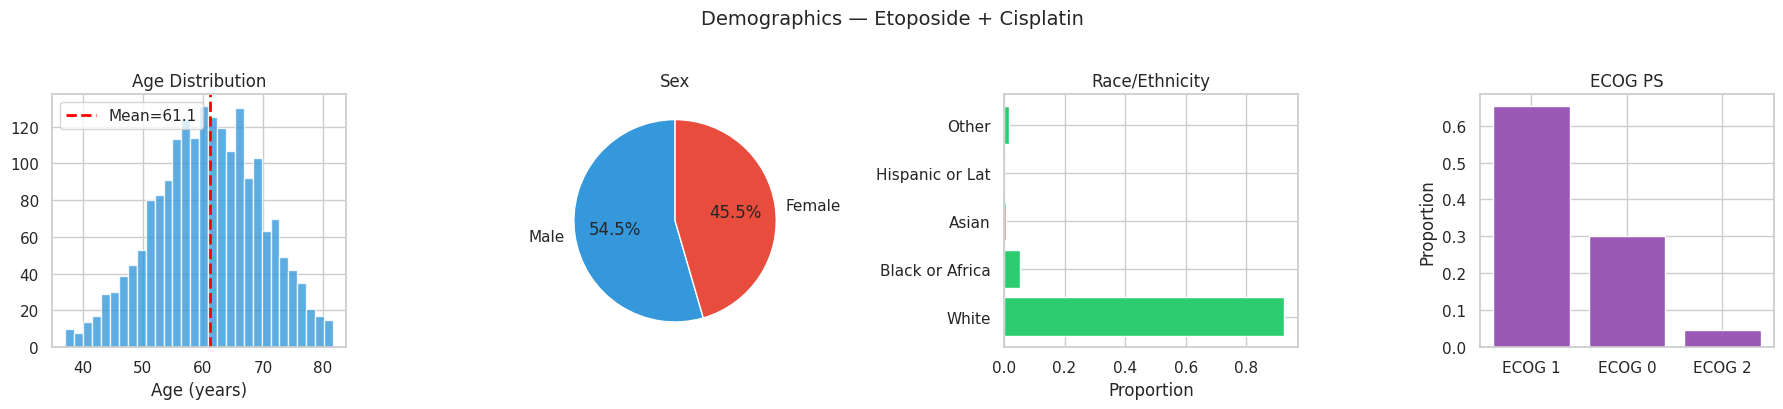

In [25]:
demo = base["demographics"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Age distribution
ax = axes[0]
age = demo["age"]["params"]
samples = np.random.normal(age["mean"], age["std"], 2000)
samples = samples[(samples >= age.get("min", 18)) & (samples <= age.get("max", 95))]
ax.hist(samples, bins=30, color="#3498db", edgecolor="white", alpha=0.8)
ax.axvline(age["mean"], color="red", linestyle="--", linewidth=2, label=f"Mean={age['mean']:.1f}")
ax.set_xlabel("Age (years)")
ax.set_title("Age Distribution")
ax.legend()

# Sex
ax = axes[1]
sex = demo["sex"]["options"]
ax.pie(sex.values(), labels=sex.keys(), autopct="%1.1f%%",
       colors=["#3498db", "#e74c3c"], startangle=90)
ax.set_title("Sex")

# Race
ax = axes[2]
race = demo.get("race", {}).get("options", {})
if race:
    labels = [k[:15] for k in race.keys()]
    ax.barh(labels, list(race.values()), color="#2ecc71")
    ax.set_xlabel("Proportion")
ax.set_title("Race/Ethnicity")

# ECOG
ax = axes[3]
ecog = demo.get("ecog_ps", {}).get("options", {})
if ecog:
    ax.bar([f"ECOG {k}" for k in ecog.keys()], list(ecog.values()), color="#9b59b6")
    ax.set_ylabel("Proportion")
ax.set_title("ECOG PS")

plt.suptitle(f"Demographics — {base['drug_name']}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4b. Adverse Event Profile

The AE profile is the core of the ruleset — it drives the simulation's toxicity model. Each AE has an incidence (0-1), grade distribution, onset timing, and duration.

**What to look for:**
- **High-frequency AEs (>50%)**: Typically hematologic (neutropenia, anemia, thrombocytopenia) for chemo drugs
- **AE count**: Should be 15-30 for most drugs (pipeline caps at 30)
- **Compare with DailyMed chart** from Section 1a: Final frequencies should be lower (0.5x dampening applied)

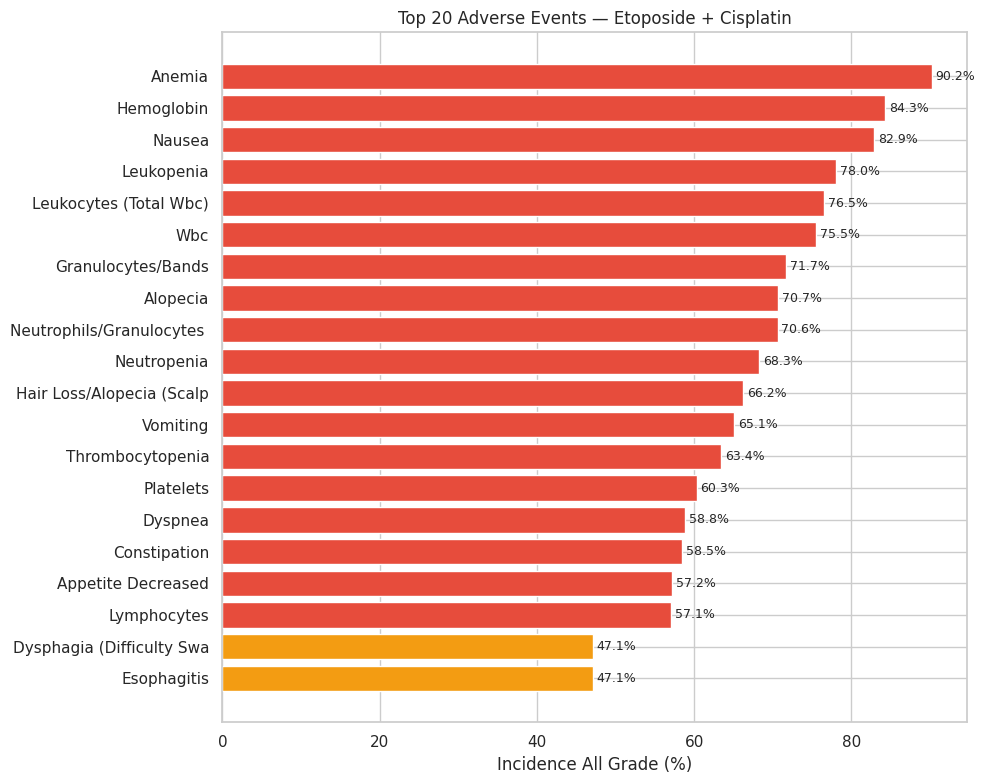

In [26]:
aes = sorted(base["ae_profile"], key=lambda x: x["incidence_all_grade"], reverse=True)

# Top 20 AEs by frequency
top_n = 20
top_aes = aes[:top_n]
terms = [ae["ae_term"].replace("_", " ").title()[:25] for ae in top_aes]
freqs = [ae["incidence_all_grade"] * 100 for ae in top_aes]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if f > 50 else "#f39c12" if f > 20 else "#3498db" for f in freqs]
bars = ax.barh(terms[::-1], freqs[::-1], color=colors[::-1])
ax.set_xlabel("Incidence All Grade (%)")
ax.set_title(f"Top {top_n} Adverse Events — {base['drug_name']}")

# Add percentage labels
for bar, val in zip(bars, freqs[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 4c. Grade Distribution (Top 10 AEs)

Each AE's severity is modeled as a grade distribution (grades 1-5), where proportions sum to ~1.0. The validator auto-corrects fabricated patterns (e.g., identical 50/30/15/5 splits across multiple AEs).

**What to look for:**
- **Hematologic AEs** (neutropenia, anemia): Should have higher grade 3-4 proportions
- **GI AEs** (nausea, vomiting): Should be mostly grade 1-2
- **Varied distributions**: If all AEs look identical, the validator's correction may not have fired — check warnings

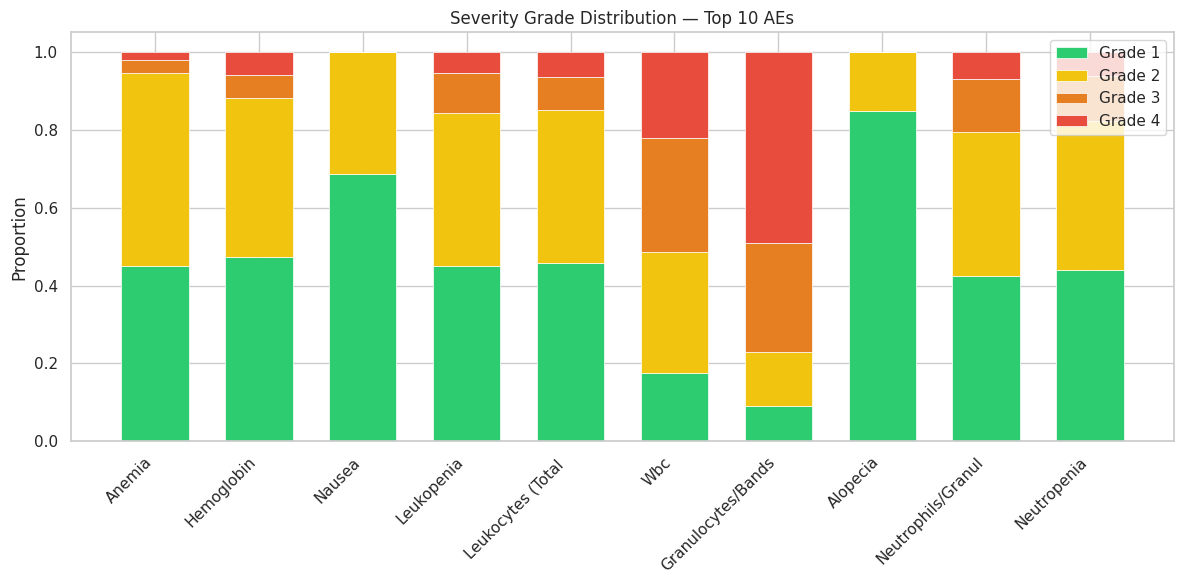

In [27]:
top10 = aes[:10]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10))
width = 0.65
grade_colors = {"1": "#2ecc71", "2": "#f1c40f", "3": "#e67e22", "4": "#e74c3c", "5": "#8e44ad"}

bottom = np.zeros(len(top10))
for grade in ["1", "2", "3", "4", "5"]:
    vals = [ae["grade_distribution"].get(grade, 0) for ae in top10]
    if any(v > 0 for v in vals):
        ax.bar(x, vals, width, bottom=bottom, label=f"Grade {grade}",
               color=grade_colors[grade], edgecolor="white", linewidth=0.5)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([ae["ae_term"].replace("_", " ").title()[:18] for ae in top10],
                    rotation=45, ha="right")
ax.set_ylabel("Proportion")
ax.set_title(f"Severity Grade Distribution — Top 10 AEs")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 4d. Efficacy

Efficacy parameters include response rates (ORR, CR) and survival distributions (PFS, OS). These are extracted from CT.gov trial outcomes and override LLM estimates when available.

**What to look for:**
- **ORR**: For platinum-based SCLC regimens, expect 60-80%; for NSCLC, 30-50%
- **PFS**: Typically 4-6 months for SCLC, 4-8 months for NSCLC
- **OS**: Typically 9-12 months for SCLC, 10-16 months for NSCLC
- If PFS/OS shows "no data", the pipeline lacked CI bounds to compute distribution parameters

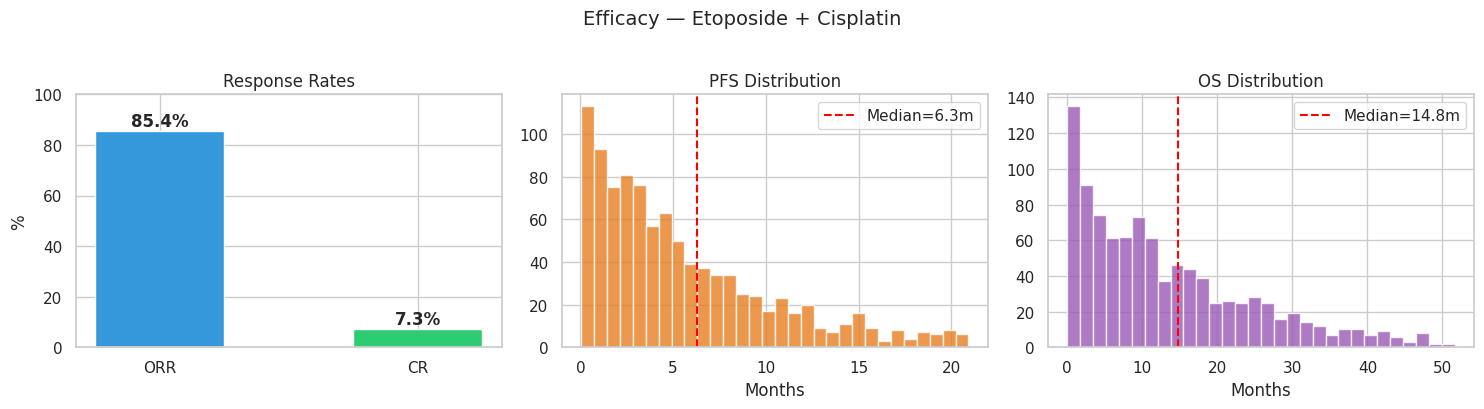

In [28]:
eff = base["efficacy"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ORR / CR
ax = axes[0]
orr = eff.get("overall_response_rate", 0) or 0
cr = eff.get("complete_response_rate", 0) or 0
ax.bar(["ORR", "CR"], [orr * 100, cr * 100], color=["#3498db", "#2ecc71"], width=0.5)
ax.set_ylabel("%")
ax.set_title("Response Rates")
ax.set_ylim(0, 100)
for i, v in enumerate([orr * 100, cr * 100]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")

# PFS
ax = axes[1]
pfs = eff.get("progression_free_survival_months", {})
if pfs and pfs.get("params"):
    p = pfs["params"]
    samples = np.random.exponential(p["mean"], 1000)
    samples = samples[(samples >= p.get("min", 0)) & (samples <= p.get("max", 60))]
    ax.hist(samples, bins=30, color="#e67e22", edgecolor="white", alpha=0.8)
    ax.axvline(p["mean"], color="red", linestyle="--", label=f"Median={p['mean']:.1f}m")
    ax.legend()
ax.set_xlabel("Months")
ax.set_title("PFS Distribution")

# OS
ax = axes[2]
os_data = eff.get("overall_survival_months", {})
if os_data and os_data.get("params"):
    p = os_data["params"]
    samples = np.random.exponential(p["mean"], 1000)
    samples = samples[(samples >= p.get("min", 0)) & (samples <= p.get("max", 120))]
    ax.hist(samples, bins=30, color="#9b59b6", edgecolor="white", alpha=0.8)
    ax.axvline(p["mean"], color="red", linestyle="--", label=f"Median={p['mean']:.1f}m")
    ax.legend()
ax.set_xlabel("Months")
ax.set_title("OS Distribution")

plt.suptitle(f"Efficacy — {base['drug_name']}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4e. Administration Schedule

The dosing regimen: which drug, what dose, which route, and on which cycle days. This is one of the strongest-scoring dimensions (~97% accuracy) because doses are extracted deterministically from DailyMed labels and CT.gov descriptions.

In [29]:
admin = base["administration_schedule"]

print(f"Administration Schedule ({base['trial_design']['cycle_length_days']}-day cycle):")
print("-" * 70)
for entry in admin:
    days_str = ", ".join(str(d) for d in entry.get("cycle_days", []))
    print(f"  {entry['drug_name']:25s}  {entry['dose_per_administration']:20s}  "
          f"{entry['route']:15s}  Days: {days_str}")

Administration Schedule (21-day cycle):
----------------------------------------------------------------------
  Etoposide                  100 mg/m^2            INTRAVENOUS      Days: 1
  Cisplatin                  80 mg/m^2             INTRAVENOUS      Days: 1


### 4f. Comorbidities & Dose Modification Rules

In [30]:
# Comorbidities
print("Comorbidities:")
for c in base.get("comorbidities", []):
    mods = len(c.get("conditional_modifiers", []))
    print(f"  {c['condition']:30s}  prevalence={c['base_probability']:.1%}  "
          f"modifiers={mods}")

# Dose modification rules
print(f"\nDose Modification Rules: {len(base.get('dose_modification_rules', []))}")
for rule in base.get("dose_modification_rules", [])[:5]:
    print(f"  {rule.get('ae_term', 'N/A'):25s}  {rule.get('grade_threshold', 'N/A')}  "
          f"-> {rule.get('action', 'N/A')}")

# AE cascade rules
print(f"\nAE Cascade Rules: {len(base.get('ae_cascade_rules', []))}")
for rule in base.get("ae_cascade_rules", [])[:5]:
    print(f"  {rule.get('trigger_ae', 'N/A'):25s}  -> {rule.get('resulting_ae', 'N/A'):25s}  "
          f"p={rule.get('probability', 0):.0%}")

Comorbidities:
  age_>_65                        prevalence=50.0%  modifiers=0
  ecog_ps_1                       prevalence=65.2%  modifiers=0
  ecog_ps_2                       prevalence=4.8%  modifiers=0

Dose Modification Rules: 7
  anemia                     N/A  -> N/A
  nausea                     N/A  -> N/A
  vomiting                   N/A  -> N/A
  thrombocytopenia           N/A  -> N/A
  appetite_decreased         N/A  -> N/A

AE Cascade Rules: 0


---
## Summary

This notebook walked through the complete pipeline:

1. **Evidence Collection** — 10 databases (6 API + 3 local + 1 remote) queried in parallel
2. **Stage 1** — 5 parallel LLM calls extract AE freq, severity, onset, triggers, demographics
3. **Stage 2** — Grounding verification (gracefully degrades)
4. **Stage 3** — Final JSON synthesis with aggressive repair
5. **Overrides** — 5 deterministic evidence-based corrections
6. **Re-prompts** — Up to 5 LLM fallback calls for missing data
7. **Validation** — Auto-correction of hallucination patterns
8. **Output** — Split into `base.json` + type overlay

To generate rulesets for other drugs, change `DRUGS` and `INDICATION` in Section 0 and re-run.